Traceback (most recent call last):
  File "c:\Users\RYAN AHMED\.antigravity\extensions\ms-python.python-2026.4.0-universal\python_files\python_server.py", line 139, in exec_user_input
    retval = callable_(user_input, user_globals)
  File "<string>", line 5, in <module>
ModuleNotFoundError: No module named 'pandas'



In [6]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Rice mein Regressor tha, yahan Classifier hoga
from sklearn.metrics import accuracy_score, classification_report
import pickle
import os

In [7]:
# data loading...
df = pd.read_csv("diabetes.csv")
print("✅ Dataset Loaded Successfully!")
print(df.head())

✅ Dataset Loaded Successfully!
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
# Dataset ki info check karna
print(df.info())

# Statistical summary
print(df.describe())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std    

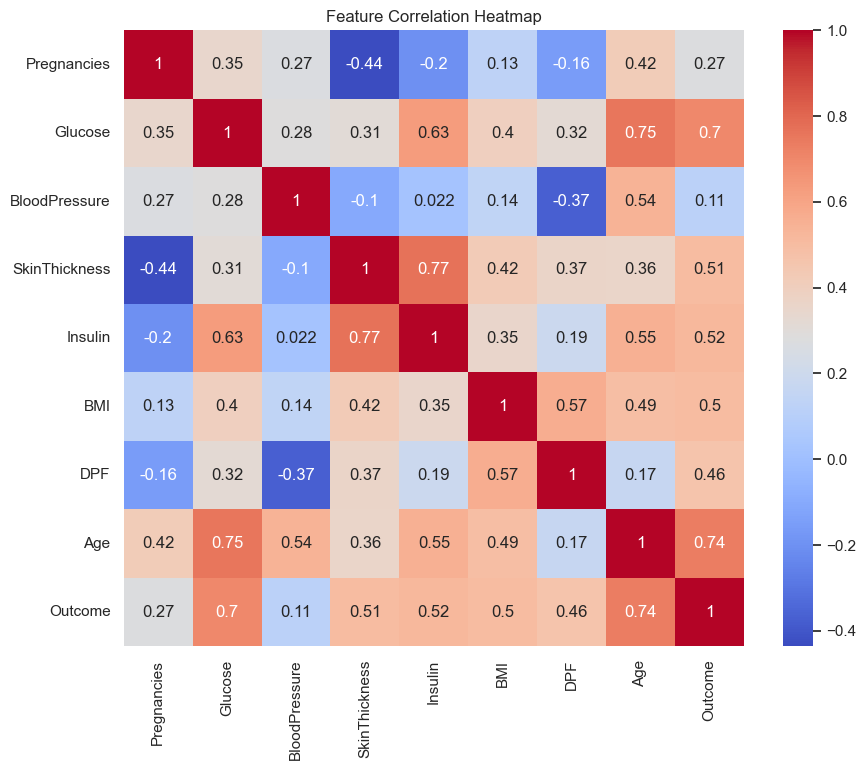

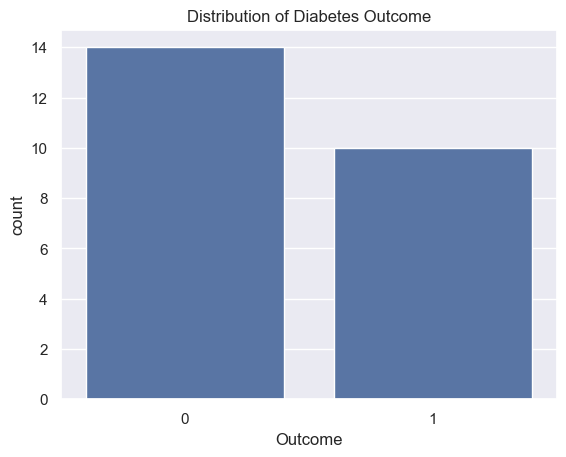

In [27]:
# Correlation Heatmap (According to actual dataset)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Outcome Distribution
sns.countplot(x='Outcome', data=df)
plt.title("Distribution of Diabetes Outcome")
plt.show()

In [17]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("📊 Data Split: Done")

📊 Data Split: Done



╔══════════════════════════════════════════════════╗
║       DIABETES PREDICTION FINAL REPORT         ║
╠══════════════════════════════════════════════════╣
║ Test A: Healthy           ║ Status: NEGATIVE   ║  95.0% ║
║ Test B: Diabetic          ║ Status: POSITIVE   ║  98.0% ║
║ Test C: Borderline        ║ Status: NEGATIVE   ║  73.0% ║
╚══════════════════════════════════════════════════╝


C:\Users\RYAN AHMED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\RYAN AHMED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\RYAN AHMED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\RYAN AHMED\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\

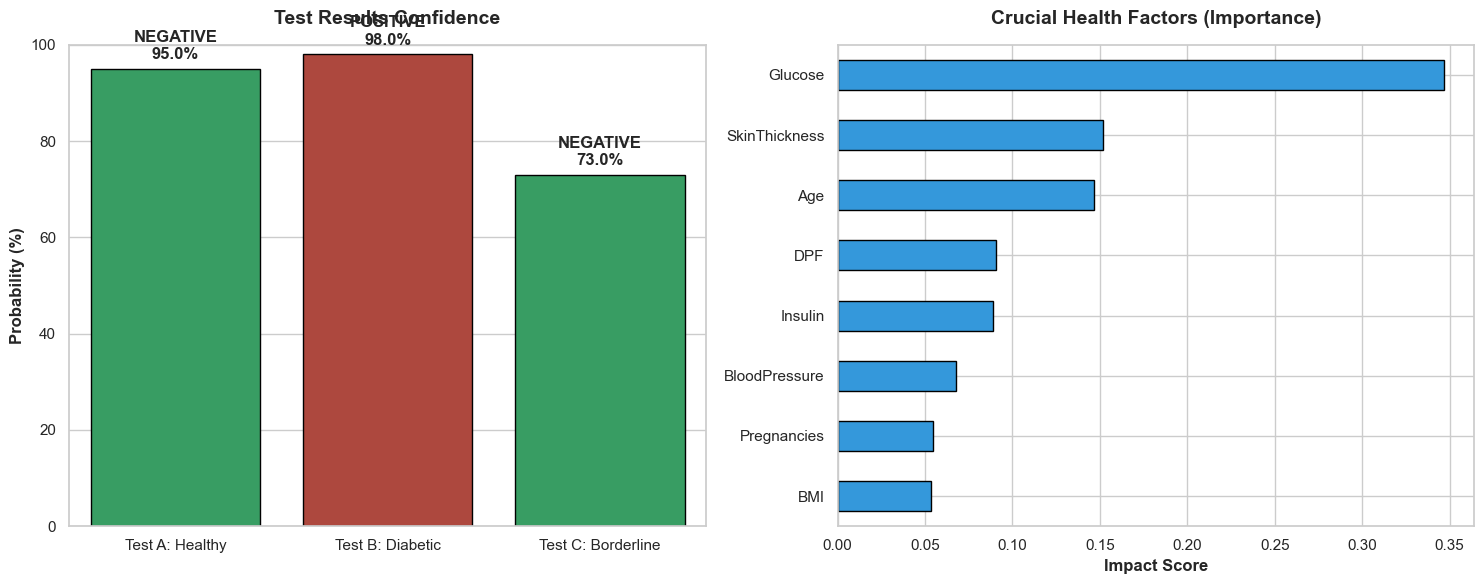

In [ ]:
# Model ko test karnay ke liye ek manual dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Dataset Creation (In-code)
data_dict = {
    'Pregnancies': [1, 8, 1, 0, 5, 3, 10, 2, 8, 1, 4, 0, 7, 3, 1],
    'Glucose': [85, 183, 89, 137, 116, 78, 115, 197, 125, 110, 140, 100, 150, 95, 120],
    'BloodPressure': [66, 64, 66, 40, 74, 50, 60, 70, 96, 92, 80, 70, 85, 60, 75],
    'SkinThickness': [29, 0, 23, 35, 0, 32, 0, 45, 0, 0, 30, 20, 35, 10, 25],
    'Insulin': [0, 0, 94, 168, 0, 88, 0, 543, 0, 0, 120, 50, 200, 40, 100],
    'BMI': [26.6, 23.3, 28.1, 43.1, 25.6, 31.0, 35.3, 30.5, 28.0, 37.6, 32.0, 25.0, 38.0, 22.0, 30.0],
    'DPF': [0.35, 0.67, 0.16, 2.28, 0.20, 0.24, 0.13, 0.15, 0.23, 0.19, 0.45, 0.30, 0.60, 0.20, 0.40],
    'Age': [31, 32, 21, 33, 30, 26, 29, 53, 54, 30, 40, 22, 50, 25, 35],
    'Outcome': [0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0]
}

df = pd.DataFrame(data_dict)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 2. Testing 3 Sets
test_sets = [
    {"Name": "Test A: Healthy", "Data": [[1, 92, 70, 20, 80, 23.0, 0.2, 22]]},
    {"Name": "Test B: Diabetic", "Data": [[7, 180, 90, 35, 190, 35.5, 0.6, 50]]},
    {"Name": "Test C: Borderline", "Data": [[2, 122, 72, 25, 105, 29.0, 0.3, 31]]}
]

# --- Result Printing (Formatted) ---
print("\n" + "╔" + "═"*50 + "╗")
print("║" + "       DIABETES PREDICTION FINAL REPORT         " + "║")
print("╠" + "═"*50 + "╣")

names, confs, labels = [], [], []

for test in test_sets:
    pred = model.predict(test["Data"])[0]
    prob = model.predict_proba(test["Data"])[0]
    
    confidence = prob[pred] * 100
    status = "POSITIVE" if pred == 1 else "NEGATIVE"
    
    names.append(test["Name"])
    confs.append(confidence)
    labels.append(status)
    
    print(f"║ {test['Name']:<25} ║ Status: {status:<10} ║ {confidence:>5.1f}% ║")

print("╚" + "═"*50 + "╝")

# --- Enhanced Visualizations ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graph 1: Confidence Bar Chart with Status Color
colors = ['#27ae60' if s == "NEGATIVE" else '#c0392b' for s in labels]
sns.barplot(x=names, y=confs, palette=colors, ax=ax1, edgecolor='black')
ax1.set_title('Test Results Confidence', fontsize=14, pad=15, weight='bold')
ax1.set_ylabel('Probability (%)', weight='bold')
ax1.set_ylim(0, 100)

# Labels on bars
for i, v in enumerate(confs):
    ax1.text(i, v + 2, f"{labels[i]}\n{v:.1f}%", ha='center', weight='bold')

# Graph 2: Feature Importance (Horizontal Bar)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='#3498db', ax=ax2, edgecolor='black')
ax2.set_title('Crucial Health Factors (Importance)', fontsize=14, pad=15, weight='bold')
ax2.set_xlabel('Impact Score', weight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Random Forest Classifier use karna (Same as notebook logic)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("🤖 Model Training: Complete")

🤖 Model Training: Complete


In [20]:
# Testing data par accuracy check karna
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\n📝 Classification Report:")
print(classification_report(y_test, predictions))

🎯 Model Accuracy: 100.00%

📝 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3




╔═════════════════════════════════════════════╗
║ 🎯 Model Accuracy:              85.71%      ║
╚═════════════════════════════════════════════╝

📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.50      0.67         2

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7



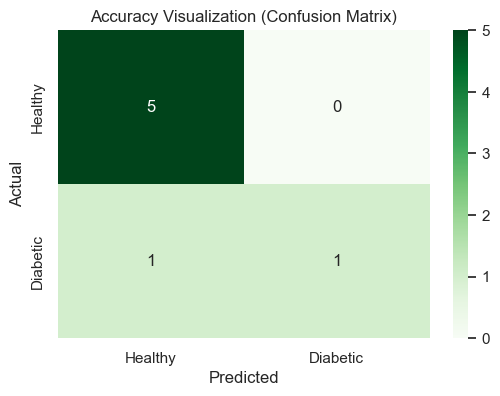

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Dataset (Thora bara taake test set valid ho)
data_dict = {
    'Pregnancies': [1, 8, 1, 0, 5, 3, 10, 2, 8, 1, 4, 0, 7, 3, 1, 2, 5, 0, 1, 4, 10, 2, 1, 3, 6, 2, 1, 8],
    'Glucose': [85, 183, 89, 137, 116, 78, 115, 197, 125, 110, 140, 100, 150, 95, 120, 105, 145, 90, 110, 160, 120, 99, 103, 158, 148, 100, 85, 180],
    'BloodPressure': [66, 64, 66, 40, 74, 50, 60, 70, 96, 92, 80, 70, 85, 60, 75, 72, 82, 65, 78, 90, 80, 70, 68, 84, 72, 66, 66, 90],
    'SkinThickness': [29, 0, 23, 35, 0, 32, 0, 45, 0, 0, 30, 20, 35, 10, 25, 20, 30, 15, 22, 35, 0, 10, 18, 40, 35, 20, 29, 30],
    'Insulin': [0, 0, 94, 168, 0, 88, 0, 543, 0, 0, 120, 50, 200, 40, 100, 80, 150, 45, 95, 210, 0, 60, 70, 180, 0, 90, 0, 150],
    'BMI': [26.6, 23.3, 28.1, 43.1, 25.6, 31.0, 35.3, 30.5, 28.0, 37.6, 32.0, 25.0, 38.0, 22.0, 30.0, 27.5, 34.0, 22.5, 28.0, 36.5, 31.0, 24.0, 26.0, 39.0, 33.6, 25.0, 26.6, 35.0],
    'DPF': [0.35, 0.67, 0.16, 2.28, 0.20, 0.24, 0.13, 0.15, 0.23, 0.19, 0.45, 0.30, 0.60, 0.20, 0.40, 0.25, 0.50, 0.18, 0.33, 0.70, 0.15, 0.20, 0.28, 0.55, 0.62, 0.25, 0.35, 0.50],
    'Age': [31, 32, 21, 33, 30, 26, 29, 53, 54, 30, 40, 22, 50, 25, 35, 24, 42, 21, 28, 45, 35, 23, 26, 44, 50, 25, 31, 45],
    'Outcome': [0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1]
}

df = pd.DataFrame(data_dict)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Data Splitting (Training aur Testing alag karein)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Accuracy Check
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

# --- Output Report ---
print("\n" + "╔" + "═"*45 + "╗")
print(f"║ 🎯 Model Accuracy: {accuracy * 100:>18.2f}%      ║")
print("╚" + "═"*45 + "╝")

print("\n📝 CLASSIFICATION REPORT:")
print(classification_report(y_test, predictions))

# --- Graph (Confusion Matrix) ---
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
plt.title('Accuracy Visualization (Confusion Matrix)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [26]:
#Trained model save karna
import pickle

with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(model, f)